In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [3]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [ ]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()  

(100, 6)


,col1,col2,col3,col4,col5,target
0,-1.612225,-0.771109,2.803119,-1.752424,-2.698038,0
1,-0.839813,2.966056,2.380321,-1.076746,-2.167128,0
2,-1.394938,-0.305522,1.293689,-0.953906,-1.378082,0
3,-2.232044,0.808228,2.686091,1.883232,-0.716867,1
4,-0.501354,-1.333155,-0.733457,0.096943,0.842029,0


In [5]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [13]:
# function for feature sampling

import random

def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [14]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [15]:
df1 = combined_sampling(df,0.5,0.5)

C:\Users\Om\AppData\Local\Temp\ipykernel_5096\1054447220.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [16]:
df2 = combined_sampling(df,0.5,0.5)

C:\Users\Om\AppData\Local\Temp\ipykernel_5096\1054447220.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [17]:
df3 = combined_sampling(df,0.5,0.5)

C:\Users\Om\AppData\Local\Temp\ipykernel_5096\1054447220.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [18]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col1', 'col4', 'target'], dtype='object')
Index(['col1', 'col4', 'target'], dtype='object')
Index(['col2', 'col3', 'target'], dtype='object')


In [19]:
df3

,col2,col3,target
36,-1.096838,-0.320786,0
37,-0.328671,2.686161,0
0,-0.771109,2.803119,0
9,-1.252067,1.556493,1
23,-1.463546,0.192041,0
23,-1.463546,0.192041,0
94,-1.130185,-0.971869,0
75,-5.228630,1.526271,0
36,-1.096838,-0.320786,0
36,-1.096838,-0.320786,0


In [20]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [21]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

DecisionTreeClassifier()

In [22]:
from sklearn.tree import plot_tree

[Text(0.6666666666666666, 0.9, 'x[1] <= -0.132\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.5, 0.7, 'x[0] <= -0.309\ngini = 0.191\nsamples = 28\nvalue = [25, 3]'),
 Text(0.5833333333333333, 0.8, 'True  '),
 Text(0.3333333333333333, 0.5, 'x[1] <= -0.569\ngini = 0.137\nsamples = 27\nvalue = [25, 2]'),
 Text(0.16666666666666666, 0.3, 'gini = 0.0\nsamples = 22\nvalue = [22, 0]'),
 Text(0.5, 0.3, 'x[0] <= -0.796\ngini = 0.48\nsamples = 5\nvalue = [3, 2]'),
 Text(0.3333333333333333, 0.1, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.6666666666666666, 0.1, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.6666666666666666, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8333333333333334, 0.7, 'gini = 0.0\nsamples = 22\nvalue = [0, 22]'),
 Text(0.75, 0.8, '  False')]

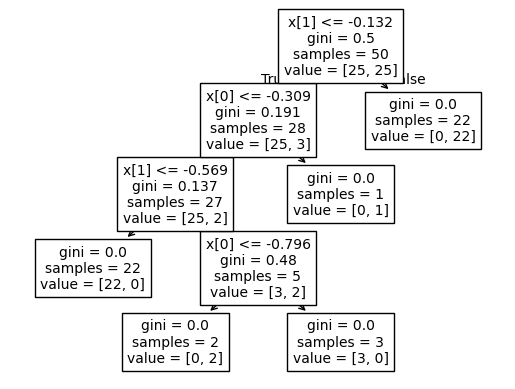

In [23]:
plot_tree(clf1)

[Text(0.6666666666666666, 0.875, 'x[1] <= -0.111\ngini = 0.497\nsamples = 50\nvalue = [27, 23]'),
 Text(0.5, 0.625, 'x[0] <= -2.043\ngini = 0.069\nsamples = 28\nvalue = [27, 1]'),
 Text(0.5833333333333333, 0.75, 'True  '),
 Text(0.3333333333333333, 0.375, 'x[0] <= -2.226\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.16666666666666666, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.5, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.6666666666666666, 0.375, 'gini = 0.0\nsamples = 25\nvalue = [25, 0]'),
 Text(0.8333333333333334, 0.625, 'gini = 0.0\nsamples = 22\nvalue = [0, 22]'),
 Text(0.75, 0.75, '  False')]

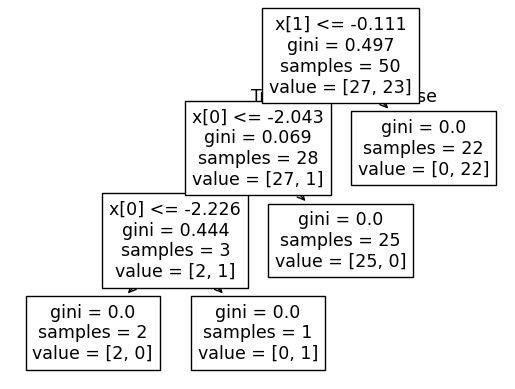

In [24]:
plot_tree(clf2)

[Text(0.40476190476190477, 0.9444444444444444, 'x[0] <= -1.843\ngini = 0.435\nsamples = 50\nvalue = [34, 16]'),
 Text(0.35714285714285715, 0.8333333333333334, 'gini = 0.0\nsamples = 9\nvalue = [9, 0]'),
 Text(0.38095238095238093, 0.8888888888888888, 'True  '),
 Text(0.4523809523809524, 0.8333333333333334, 'x[0] <= 0.954\ngini = 0.476\nsamples = 41\nvalue = [25, 16]'),
 Text(0.4285714285714286, 0.8888888888888888, '  False'),
 Text(0.40476190476190477, 0.7222222222222222, 'x[1] <= 0.599\ngini = 0.494\nsamples = 36\nvalue = [20, 16]'),
 Text(0.19047619047619047, 0.6111111111111112, 'x[0] <= -0.648\ngini = 0.337\nsamples = 14\nvalue = [11, 3]'),
 Text(0.09523809523809523, 0.5, 'x[0] <= -1.586\ngini = 0.165\nsamples = 11\nvalue = [10, 1]'),
 Text(0.047619047619047616, 0.3888888888888889, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.14285714285714285, 0.3888888888888889, 'gini = 0.0\nsamples = 10\nvalue = [10, 0]'),
 Text(0.2857142857142857, 0.5, 'x[0] <= 0.047\ngini = 0.444\nsamples

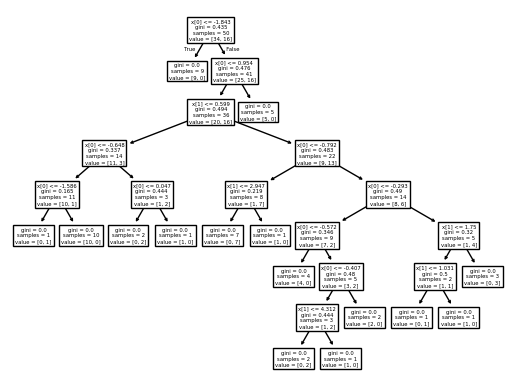

In [25]:
plot_tree(clf3)

In [26]:
clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

c:\Users\Om\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [27]:
clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

c:\Users\Om\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [28]:
clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

c:\Users\Om\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [29]:
df.sample(14,replace=True)

,col1,col2,col3,col4,col5,target
75,-0.426933,-5.228630,1.526271,-0.749674,-0.898025,0
77,-1.440552,-0.189162,2.146733,1.114550,-2.970965,1
13,-1.388169,0.702166,0.753130,-2.128849,-1.225603,0
0,-1.612225,-0.771109,2.803119,-1.752424,-2.698038,0
86,-2.006598,-1.796701,0.218524,-1.988411,-1.164121,0
86,-2.006598,-1.796701,0.218524,-1.988411,-1.164121,0
44,0.168963,-0.778522,1.893611,1.165544,-0.873793,1
35,-0.177023,-1.096746,2.376338,2.450770,-0.999319,1
50,-1.175867,0.091631,0.132983,-1.151730,-0.575863,0
97,-1.090644,-2.412873,1.986145,-1.497831,-1.509115,0
